In [83]:
import networkx as nx
import matplotlib.pyplot as plt
import random
import sys
from pathlib import Path
import random
import numpy as np
import os
import json

# Make sure src is importable
project_root = Path('..').resolve()
sys.path.insert(0, str(project_root / 'src'))
from etc.hamiltonian import Hamiltonian
from etc_utils.phase_diagrams import *

### First we define utils to build the study graphs

Graph visualization 

In [63]:
def plot_min_h_example(G, k, seed=42, title=None, layout="kamada_kawai", palette="sunset_ink"):
    Hobj = Hamiltonian(G)
    mu = Hobj.mu_density_aware(G)
    gamma = Hobj.gamma_balancer(mu=mu)
    Hmin, min_nodes = sample_k_closest_to_zero(
        H=Hobj,
        k=int(k),
        mu=mu,
        gamma=gamma,
        A=Hobj.A,
        D2=Hobj.Dinv2_triu,
        seed=seed,
    )
    min_nodes = sorted(int(x) for x in np.asarray(min_nodes).ravel())

    palettes = {
        "sunset_ink": {
            "edge": "#6B7280",
            "node_bg": "#334155",
            "node_hi": "#F97316",
            "node_hi_edge": "#111827",
            "figure_bg": "#F8F5F0",
            "text": "#1F2937",
        },
        "teal_gold": {
            "edge": "#5B7C99",
            "node_bg": "#264653",
            "node_hi": "#E9C46A",
            "node_hi_edge": "#1B1F24",
            "figure_bg": "#FAF8F2",
            "text": "#1F2937",
        },
    }
    style = palettes.get(palette, palettes["sunset_ink"])

    if layout == "kamada_kawai":
        try:
            pos = nx.kamada_kawai_layout(G)
        except Exception:
            pos = nx.spring_layout(G, seed=seed)
    elif callable(layout):
        pos = layout(G)
    else:
        pos = nx.spring_layout(G, seed=seed)

    fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
    fig.patch.set_facecolor(style["figure_bg"])
    ax.set_facecolor(style["figure_bg"])

    if title is None:
        title = f"Minimum H example for k={k}"
    ax.set_title(f"{title}\nHmin={Hmin:.6g}", color=style["text"])
    ax.axis("off")

    background = [n for n in G.nodes() if n not in min_nodes]

    nx.draw_networkx_edges(G, pos, ax=ax, width=0.4, alpha=0.55, edge_color=style["edge"])
    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=background,
        ax=ax,
        node_color=style["node_bg"],
        node_size=42,
        linewidths=0,
    )
    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=min_nodes,
        ax=ax,
        node_color=style["node_hi"],
        node_size=120,
        edgecolors=style["node_hi_edge"],
        linewidths=0.8,
    )

    print(f"Graph: n={G.number_of_nodes()}, m={G.number_of_edges()}")
    print(f"mu={mu:.6g}, gamma={gamma:.6g}")
    print(f"k={k} minimum H={Hmin:.6g}")
    print(f"Minimizing nodes: {min_nodes}")

    figures_dir = project_root / "examples/figures"
    figures_dir.mkdir(parents=True, exist_ok=True)

    filename = f"G_{title}_k{k}.png"
    plt.savefig(figures_dir / filename, dpi=300)
    plt.show()

    return fig, ax, Hmin, min_nodes, mu, gamma

Graph: n=32, m=141
mu=0.715726, gamma=34.3972
k=7 minimum H=0.00264617
Minimizing nodes: [7, 9, 12, 13, 17, 18, 30]


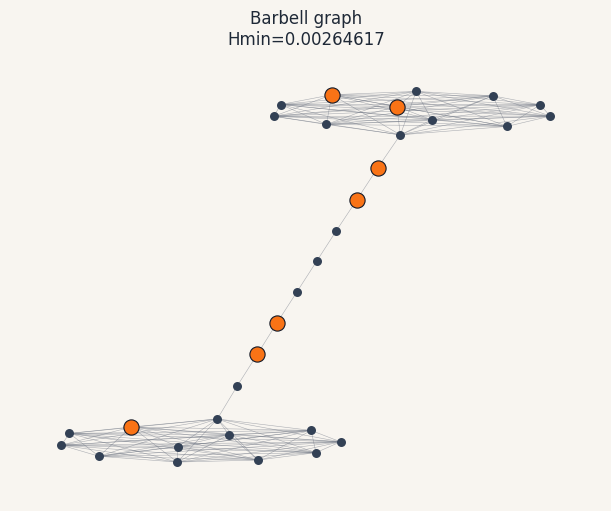

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Barbell graph\nHmin=0.00264617'}>,
 0.0026461693548389675,
 [7, 9, 12, 13, 17, 18, 30],
 0.7157258064516129,
 34.39717741935484)

In [84]:
G_barbell = nx.barbell_graph(12, 8)
plot_min_h_example(G_barbell, k=7, seed=1, title="Barbell graph")

Graph: n=32, m=141
mu=0.715726, gamma=34.3972
k=4 minimum H=0
Minimizing nodes: [3, 14, 17, 21]


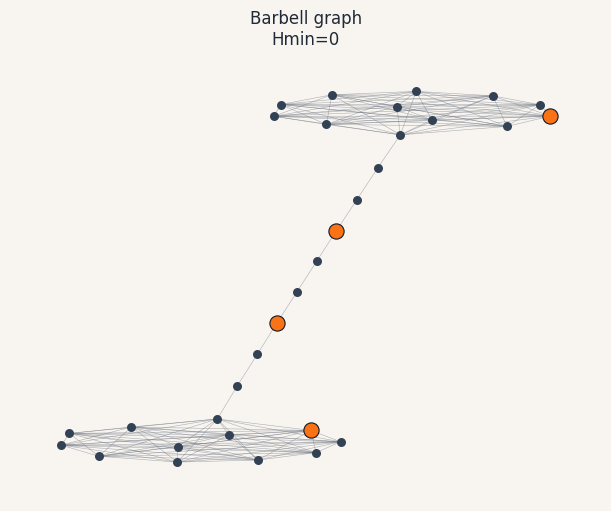

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Barbell graph\nHmin=0'}>,
 0.0,
 [3, 14, 17, 21],
 0.7157258064516129,
 34.39717741935484)

In [ ]:
plot_min_h_example(G_barbell, k=4, seed=1, title="Barbell graph")

Graph: n=32, m=141
mu=0.715726, gamma=34.3972
k=5 minimum H=0
Minimizing nodes: [4, 12, 14, 18, 21]


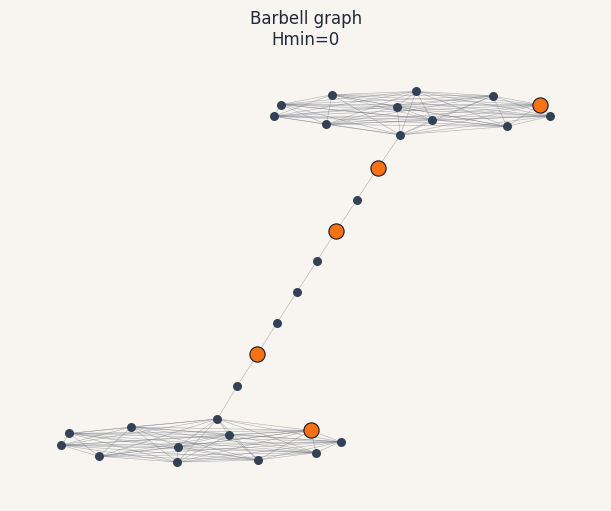

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Barbell graph\nHmin=0'}>,
 0.0,
 [4, 12, 14, 18, 21],
 0.7157258064516129,
 34.39717741935484)

In [ ]:
plot_min_h_example(G_barbell, k=5, seed=2, title="Barbell graph")

Graph: n=150, m=604
mu=0.945951, gamma=1.35123
k=5 minimum H=0
Minimizing nodes: [79, 104, 129, 132, 143]


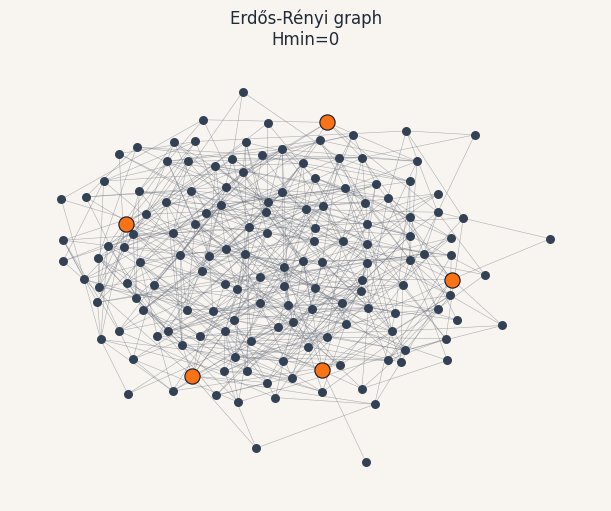

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Erdős-Rényi graph\nHmin=0'}>,
 0.0,
 [79, 104, 129, 132, 143],
 0.9459507829977629,
 1.3512304250559286)

In [85]:
G_rand = nx.erdos_renyi_graph(150, 0.05, seed=1)
plot_min_h_example(G_rand, k=5, seed=2, title="Erdős-Rényi graph")

Graph: n=150, m=604
mu=0.945951, gamma=1.35123
k=20 minimum H=-2.48571e-06
Minimizing nodes: [1, 2, 3, 4, 6, 10, 11, 12, 16, 19, 28, 29, 33, 34, 43, 44, 52, 57, 101, 125]


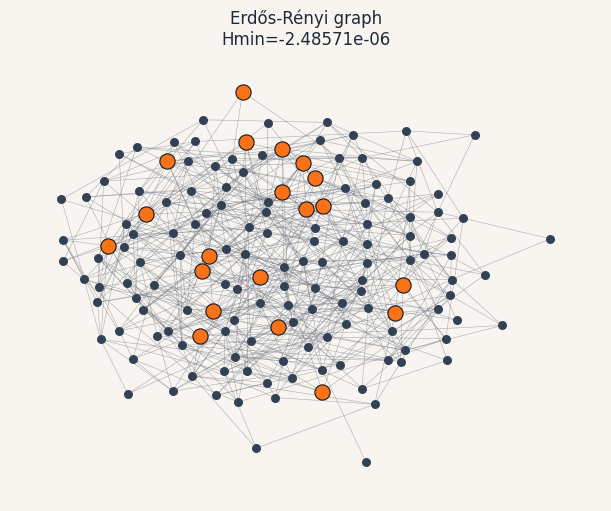

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Erdős-Rényi graph\nHmin=-2.48571e-06'}>,
 -2.4857071814210485e-06,
 [1, 2, 3, 4, 6, 10, 11, 12, 16, 19, 28, 29, 33, 34, 43, 44, 52, 57, 101, 125],
 0.9459507829977629,
 1.3512304250559286)

In [ ]:
plot_min_h_example(G_rand, k=20, seed=2, title="Erdős-Rényi graph")

Graph: n=150, m=604
mu=0.945951, gamma=1.35123
k=10 minimum H=-0.000447427
Minimizing nodes: [3, 9, 25, 32, 33, 70, 86, 118, 121, 126]


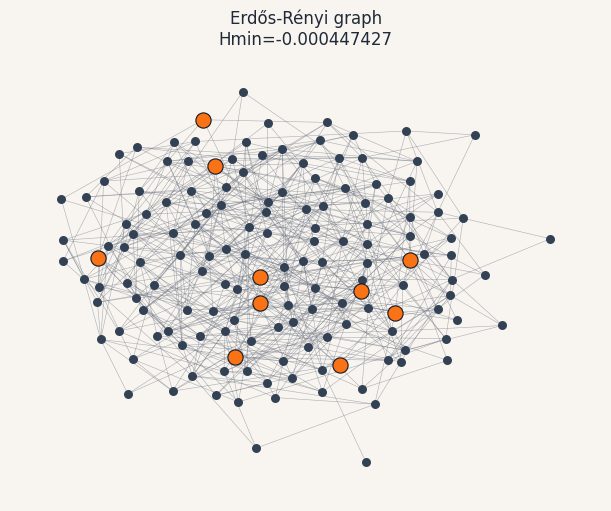

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Erdős-Rényi graph\nHmin=-0.000447427'}>,
 -0.0004474272930643508,
 [3, 9, 25, 32, 33, 70, 86, 118, 121, 126],
 0.9459507829977629,
 1.3512304250559286)

In [ ]:
plot_min_h_example(G_rand, k=10, seed=2, title="Erdős-Rényi graph")

In [86]:
G_regular = nx.random_regular_graph(4,150)

Graph: n=150, m=604
mu=0.945951, gamma=1.35123
k=10 minimum H=-0.000447427
Minimizing nodes: [13, 31, 64, 94, 114, 119, 130, 133, 134, 145]


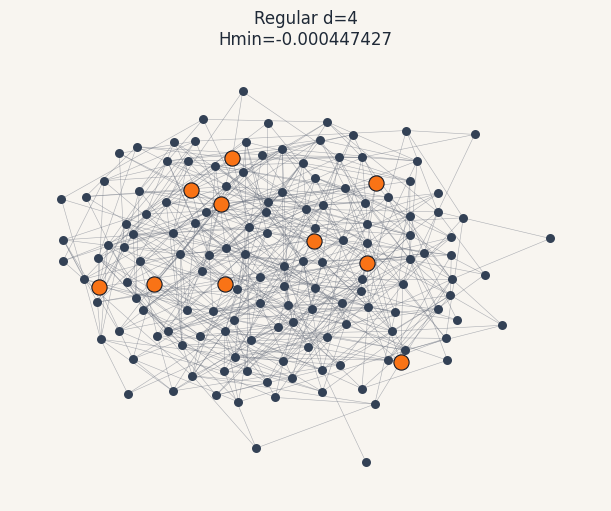

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Regular d=4\nHmin=-0.000447427'}>,
 -0.0004474272930643508,
 [13, 31, 64, 94, 114, 119, 130, 133, 134, 145],
 0.9459507829977629,
 1.3512304250559286)

In [ ]:
plot_min_h_example(G_regular, k=10, seed=1, title="Regular d=4")

Graph: n=150, m=604
mu=0.945951, gamma=1.35123
k=20 minimum H=0.000444942
Minimizing nodes: [0, 7, 10, 15, 20, 22, 25, 33, 36, 45, 50, 51, 53, 54, 57, 64, 88, 103, 106, 127]


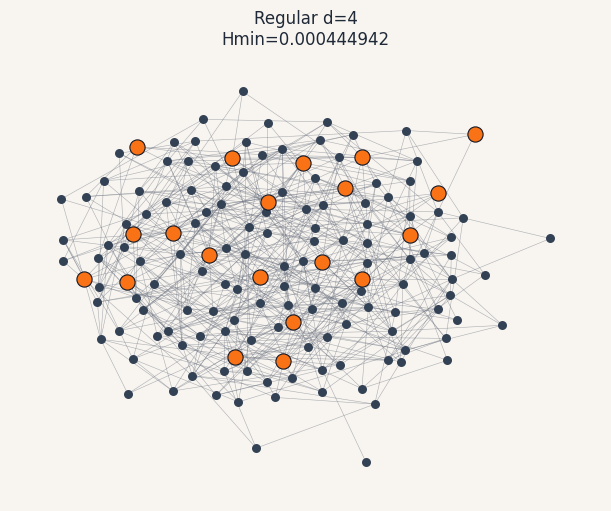

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Regular d=4\nHmin=0.000444942'}>,
 0.00044494158588292976,
 [0,
  7,
  10,
  15,
  20,
  22,
  25,
  33,
  36,
  45,
  50,
  51,
  53,
  54,
  57,
  64,
  88,
  103,
  106,
  127],
 0.9459507829977629,
 1.3512304250559286)

In [ ]:
plot_min_h_example(G_regular, k=20, seed=1, title="Regular d=4")

Graph: n=150, m=604
mu=0.945951, gamma=1.35123
k=30 minimum H=0.000889883
Minimizing nodes: [0, 1, 2, 4, 7, 8, 9, 10, 11, 14, 17, 21, 23, 25, 26, 28, 32, 33, 44, 46, 67, 70, 74, 77, 105, 113, 114, 117, 119, 139]


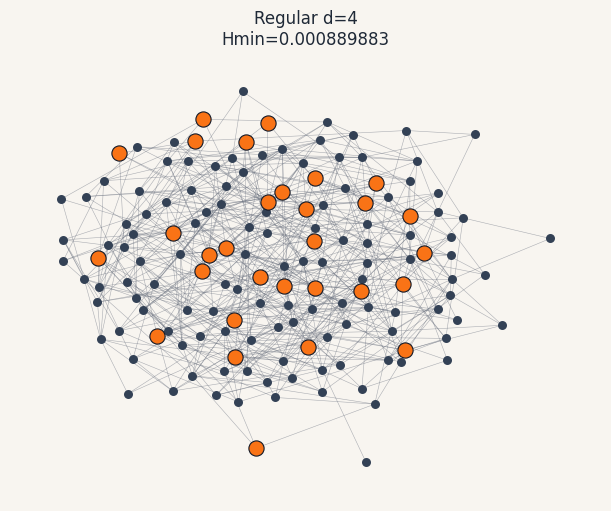

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Regular d=4\nHmin=0.000889883'}>,
 0.0008898831717658595,
 [0,
  1,
  2,
  4,
  7,
  8,
  9,
  10,
  11,
  14,
  17,
  21,
  23,
  25,
  26,
  28,
  32,
  33,
  44,
  46,
  67,
  70,
  74,
  77,
  105,
  113,
  114,
  117,
  119,
  139],
 0.9459507829977629,
 1.3512304250559286)

In [ ]:
plot_min_h_example(G_regular, k=30, seed=1, title="Regular d=4")

In [87]:
G_ba = nx.barabasi_albert_graph(n=200, m=4, seed=42)

Graph: n=200, m=784
mu=0.960603, gamma=0.630352
k=10 minimum H=0.000491346
Minimizing nodes: [4, 13, 42, 56, 96, 98, 112, 128, 171, 197]


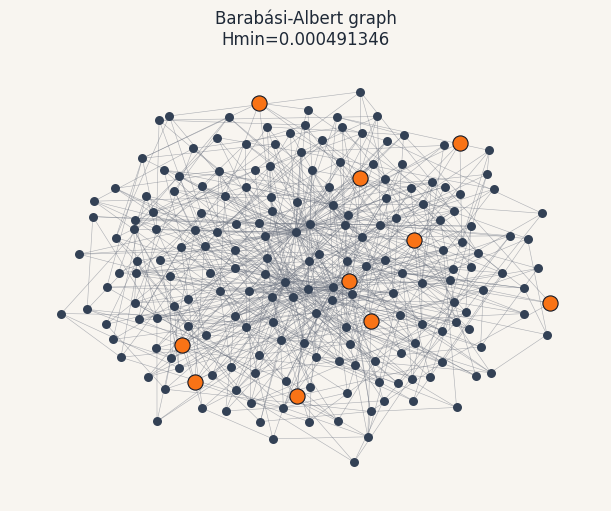

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Barabási-Albert graph\nHmin=0.000491346'}>,
 0.0004913456169735042,
 [4, 13, 42, 56, 96, 98, 112, 128, 171, 197],
 0.9606030150753769,
 0.6303517587939699)

In [ ]:
plot_min_h_example(G_ba, k=10, seed=1, title="Barabási-Albert graph")

Graph: n=200, m=784
mu=0.960603, gamma=0.630352
k=20 minimum H=2.23339e-05
Minimizing nodes: [24, 28, 33, 48, 53, 59, 62, 65, 66, 73, 74, 101, 125, 138, 153, 159, 164, 173, 184, 196]


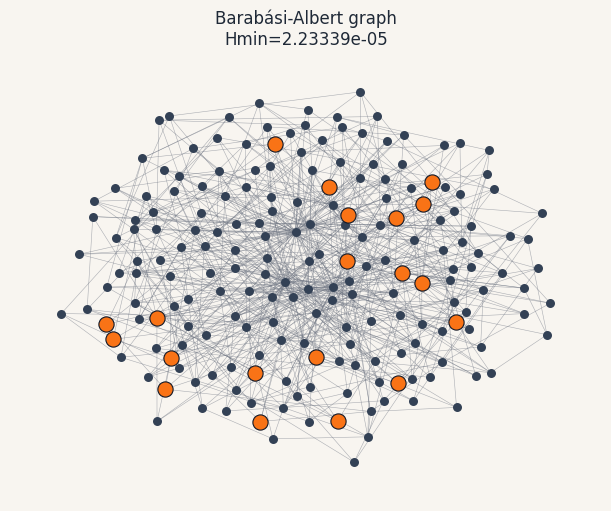

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Barabási-Albert graph\nHmin=2.23339e-05'}>,
 2.2333891680048623e-05,
 [24,
  28,
  33,
  48,
  53,
  59,
  62,
  65,
  66,
  73,
  74,
  101,
  125,
  138,
  153,
  159,
  164,
  173,
  184,
  196],
 0.9606030150753769,
 0.6303517587939699)

In [ ]:
plot_min_h_example(G_ba, k=20, seed=1, title="Barabási-Albert graph")

Graph: n=200, m=784
mu=0.960603, gamma=0.630352
k=40 minimum H=0.000111669
Minimizing nodes: [1, 10, 13, 17, 18, 20, 23, 24, 27, 32, 35, 37, 45, 52, 62, 68, 73, 83, 85, 89, 92, 94, 103, 106, 107, 110, 114, 120, 122, 133, 141, 147, 168, 179, 180, 183, 185, 192, 193, 194]


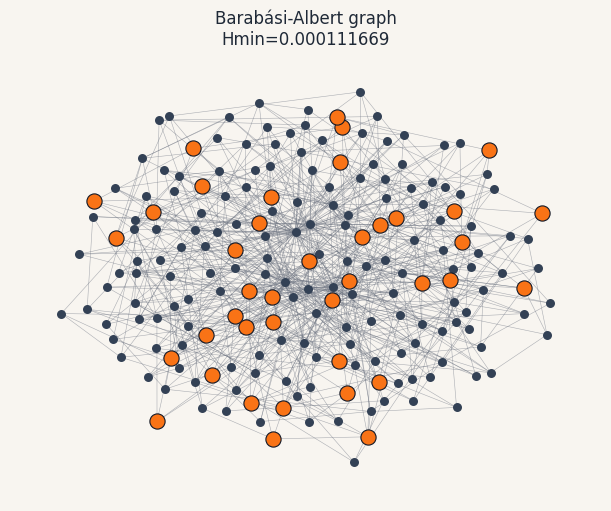

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Barabási-Albert graph\nHmin=0.000111669'}>,
 0.00011166945840557219,
 [1,
  10,
  13,
  17,
  18,
  20,
  23,
  24,
  27,
  32,
  35,
  37,
  45,
  52,
  62,
  68,
  73,
  83,
  85,
  89,
  92,
  94,
  103,
  106,
  107,
  110,
  114,
  120,
  122,
  133,
  141,
  147,
  168,
  179,
  180,
  183,
  185,
  192,
  193,
  194],
 0.9606030150753769,
 0.6303517587939699)

In [ ]:
plot_min_h_example(G_ba, k=40, seed=42, title="Barabási-Albert graph")

In [80]:
def plot_phase_diagram_for_graph(
    G,
    *,
    mu=1.0,
    gamma=1.0,
    kmax=20,
    scale_max=12,
    scale_steps=1,
    k_steps=1,
    cmap="cividis",
    contour_color="#243B53",
    title="Phase Diagram",
):
    H_obj = Hamiltonian(G)
    A = np.triu(nx.to_numpy_array(G))
    D2 = H_obj.Dinv2_triu

    pd = phase_diagram_values(
        A=A,
        D2=D2,
        Hamiltonian=H_obj,
        mu=float(mu),
        gamma=float(gamma),
        kmax=int(kmax),
        scale_max=int(scale_max),
        scale_steps=int(scale_steps),
        k_steps=int(k_steps),
    )

    k_values = sorted(pd.keys())
    scale_values = sorted(pd[k_values[0]].keys())
    hmin_arr = np.array([[pd[k][s][1] for s in scale_values] for k in k_values], dtype=float)

    phase_bg = "#F8F5F0"
    phase_text = "#1F2937"

    fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
    fig.patch.set_facecolor(phase_bg)
    ax.set_facecolor(phase_bg)

    im = ax.imshow(
        hmin_arr,
        aspect="auto",
        origin="lower",
        interpolation="bilinear",
        cmap=cmap,
        extent=[min(scale_values), max(scale_values), min(k_values) - 0.5, max(k_values) + 0.5],
    )

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("H_min", color=phase_text)
    cbar.ax.yaxis.set_tick_params(color=phase_text)
    plt.setp(cbar.ax.get_yticklabels(), color=phase_text)

    ax.set_xlabel("Scale s", color=phase_text)
    ax.set_ylabel("k", color=phase_text)
    ax.set_title(title, color=phase_text)
    ax.tick_params(colors=phase_text)

    Xc, Yc = np.meshgrid(scale_values, k_values)
    cs = ax.contour(Xc, Yc, hmin_arr, levels=8, colors=contour_color, linewidths=0.7, alpha=0.85)
    ax.clabel(cs, inline=True, fontsize=7, fmt="%.2g")

    print(f"Graph: n={G.number_of_nodes()}, m={G.number_of_edges()}")
    print("Computed phase diagram.")

    figures_dir = project_root / "examples/figures"
    figures_dir.mkdir(parents=True, exist_ok=True)

    filename = f"PD_{title}.png"
    plt.savefig(figures_dir / filename, dpi=300)
    plt.show()

    return fig, ax, pd


Graph: n=150, m=516
Computed phase diagram.


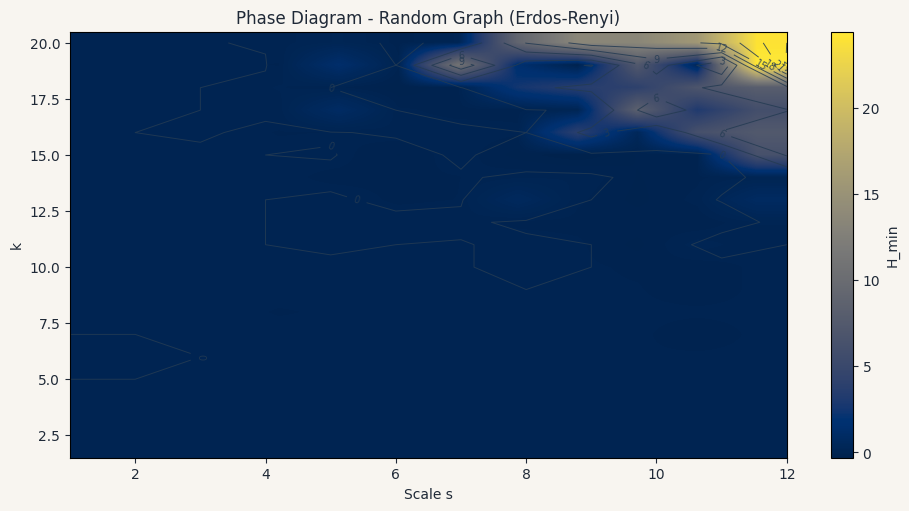

(<Figure size 900x500 with 2 Axes>,
 <Axes: title={'center': 'Phase Diagram - Random Graph (Erdos-Renyi)'}, xlabel='Scale s', ylabel='k'>,
 {2: {1: (1, 0.0),
   2: (2, 0.0),
   3: (3, 0.0),
   4: (4, 0.0),
   5: (5, 0.0),
   6: (6, 0.0),
   7: (7, 0.0),
   8: (8, 0.0),
   9: (9, 0.0),
   10: (10, 0.0),
   11: (11, 0.0),
   12: (12, 0.0)},
  3: {1: (1, 0.0),
   2: (2, 0.0),
   3: (3, 0.0),
   4: (4, 0.0),
   5: (5, 0.0),
   6: (6, 0.0),
   7: (7, 0.0),
   8: (8, 0.0),
   9: (9, 0.0),
   10: (10, 0.0),
   11: (11, 0.0),
   12: (12, 0.0)},
  4: {1: (1, 0.0),
   2: (2, 0.0),
   3: (3, 0.0),
   4: (4, 0.0),
   5: (5, 0.0),
   6: (6, 0.0),
   7: (7, 0.0),
   8: (8, 0.0),
   9: (9, 0.0),
   10: (10, 0.0),
   11: (11, 0.0),
   12: (12, 0.0)},
  5: {1: (1, 0.0),
   2: (2, 0.0),
   3: (3, 0.0),
   4: (4, 0.0),
   5: (5, 0.0),
   6: (6, 0.0),
   7: (7, 0.0),
   8: (8, 0.0),
   9: (9, 0.0),
   10: (10, 0.0),
   11: (11, 0.0),
   12: (12, 0.0)},
  6: {1: (1, 0.00694444444444442),
   2: (2, 0.013888

In [81]:
seed = 42
plot_phase_diagram_for_graph(
    G_rand,
    mu=1.0,
    gamma=1.0,
    kmax=20,
    scale_max=12,
    title="Phase Diagram - Random Graph (Erdos-Renyi)",
)

Graph: n=200, m=784
Computed phase diagram.


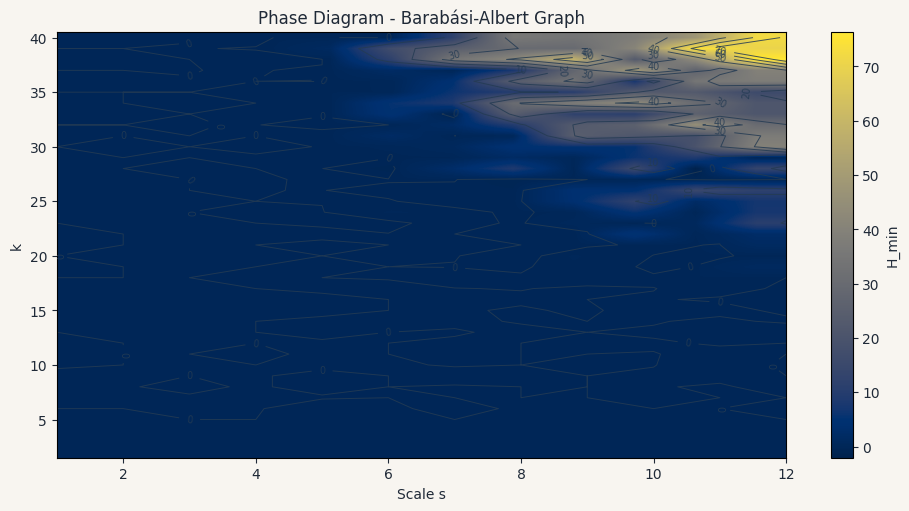

(<Figure size 900x500 with 2 Axes>,
 <Axes: title={'center': 'Phase Diagram - Barabási-Albert Graph'}, xlabel='Scale s', ylabel='k'>,
 {2: {1: (1, 0.0),
   2: (2, 0.0),
   3: (3, 0.0),
   4: (4, 0.0),
   5: (5, 0.0),
   6: (6, 0.0),
   7: (7, 0.0),
   8: (8, 0.0),
   9: (9, 0.0),
   10: (10, 0.0),
   11: (11, 0.0),
   12: (12, 0.0)},
  3: {1: (1, 0.0),
   2: (2, 0.0),
   3: (3, 0.0),
   4: (4, 0.0),
   5: (5, 0.0),
   6: (6, 0.0),
   7: (7, 0.0),
   8: (8, 0.0),
   9: (9, 0.0),
   10: (10, 0.0),
   11: (11, 0.0),
   12: (12, 0.0)},
  4: {1: (1, 0.0),
   2: (2, 0.0),
   3: (3, 0.0),
   4: (4, 0.0),
   5: (5, 0.0),
   6: (6, 0.0),
   7: (7, 0.0),
   8: (8, 0.0),
   9: (9, 0.0),
   10: (10, 0.0),
   11: (11, 0.0),
   12: (12, 0.0)},
  5: {1: (1, 0.0),
   2: (2, 0.0),
   3: (3, 0.0),
   4: (4, 0.0),
   5: (5, 0.0),
   6: (6, 0.0),
   7: (7, 0.0),
   8: (8, 0.0),
   9: (9, 0.0),
   10: (10, 0.0),
   11: (11, 0.0),
   12: (12, 0.0)},
  6: {1: (1, 0.0),
   2: (2, 0.0),
   3: (3, 0.00666666666

In [89]:
plot_phase_diagram_for_graph(G_ba,gamma=0.4,
                     mu=0.96,
                     kmax=40, 
                     scale_max=12, 
                     scale_steps=1, 
                     k_steps=1,
                     title="Phase Diagram - Barabási-Albert Graph")

Graph: n=150, m=300
Computed phase diagram.


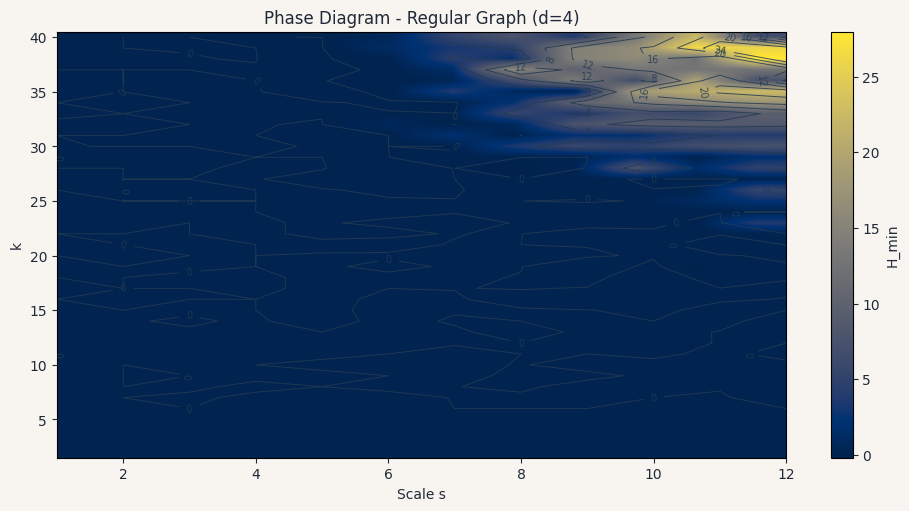

(<Figure size 900x500 with 2 Axes>,
 <Axes: title={'center': 'Phase Diagram - Regular Graph (d=4)'}, xlabel='Scale s', ylabel='k'>,
 {2: {1: (1, 0.0),
   2: (2, 0.0),
   3: (3, 0.0),
   4: (4, 0.0),
   5: (5, 0.0),
   6: (6, 0.0),
   7: (7, 0.0),
   8: (8, 0.0),
   9: (9, 0.0),
   10: (10, 0.0),
   11: (11, 0.0),
   12: (12, 0.0)},
  3: {1: (1, 0.0),
   2: (2, 0.0),
   3: (3, 0.0),
   4: (4, 0.0),
   5: (5, 0.0),
   6: (6, 0.0),
   7: (7, 0.0),
   8: (8, 0.0),
   9: (9, 0.0),
   10: (10, 0.0),
   11: (11, 0.0),
   12: (12, 0.0)},
  4: {1: (1, 0.0),
   2: (2, 0.0),
   3: (3, 0.0),
   4: (4, 0.0),
   5: (5, 0.0),
   6: (6, 0.0),
   7: (7, 0.0),
   8: (8, 0.0),
   9: (9, 0.0),
   10: (10, 0.0),
   11: (11, 0.0),
   12: (12, 0.0)},
  5: {1: (1, 0.0),
   2: (2, 0.0),
   3: (3, 0.0),
   4: (4, 0.0),
   5: (5, 0.0),
   6: (6, 0.0),
   7: (7, 0.0),
   8: (8, 0.0),
   9: (9, 0.0),
   10: (10, 0.0),
   11: (11, 0.0),
   12: (12, 0.0)},
  6: {1: (1, 0.0),
   2: (2, 0.0),
   3: (3, 0.0),
   4: (4,

In [90]:
plot_phase_diagram_for_graph(G_regular,gamma=0.4,
                     mu=0.96,
                     kmax=40, 
                     scale_max=12, 
                     scale_steps=1, 
                     k_steps=1,
                     title="Phase Diagram - Regular Graph (d=4)")

Graph: n=32, m=141
Computed phase diagram.


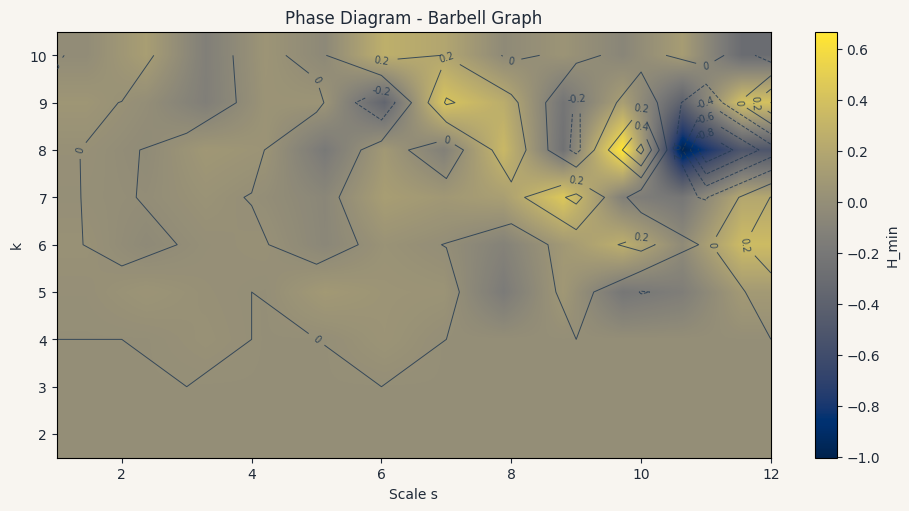

(<Figure size 900x500 with 2 Axes>,
 <Axes: title={'center': 'Phase Diagram - Barbell Graph'}, xlabel='Scale s', ylabel='k'>,
 {2: {1: (1, 0.0),
   2: (2, 0.0),
   3: (3, 0.0),
   4: (4, 0.0),
   5: (5, 0.0),
   6: (6, 0.0),
   7: (7, 0.0),
   8: (8, 0.0),
   9: (9, 0.0),
   10: (10, 0.0),
   11: (11, 0.0),
   12: (12, 0.0)},
  3: {1: (1, 0.0),
   2: (2, 0.0),
   3: (3, 0.0),
   4: (4, 0.0),
   5: (5, 0.0),
   6: (6, 0.0),
   7: (7, 0.0),
   8: (8, 0.0),
   9: (9, 0.0),
   10: (10, 0.0),
   11: (11, 0.0),
   12: (12, 0.0)},
  4: {1: (1, 0.0),
   2: (2, 0.0),
   3: (3, 0.02574074074074073),
   4: (4, 0.0),
   5: (5, 0.0),
   6: (6, 0.046735537190083054),
   7: (7, 0.0),
   8: (8, 0.0),
   9: (9, 0.0),
   10: (10, 0.0),
   11: (11, 0.0),
   12: (12, 0.0)},
  5: {1: (1, 0.009031033901163443),
   2: (2, 0.047483555405633204),
   3: (3, 0.016989795918366912),
   4: (4, 0.0),
   5: (5, 0.08956790123456804),
   6: (6, 0.05148148148148146),
   7: (7, 0.04249999999999998),
   8: (8, -0.16969135

In [92]:
plot_phase_diagram_for_graph(G_barbell,gamma=20,
                     mu=0.715,
                     kmax=10, 
                     scale_max=12, 
                     scale_steps=1, 
                     k_steps=1,
                     title="Phase Diagram - Barbell Graph")